# Mess3 Transformer: Non-Ergodic Dataset

Train a transformer on sequences from multiple Mess3 instances (different α, x parameters).
Each training sequence is a single ergodic Mess3 instance. Analyse residual stream via PCA.

In [29]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
import wandb

from mess3 import Mess3, Mess3Dataset
from transformer import GPT
from plots import (plot_training_loss, plot_per_instance_loss, plot_pca_per_instance,
                   plot_cev_per_instance, plot_steps_x_instances_grid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using cuda


## 1. Create non-ergodic dataset

Multiple Mess3 instances with different (α, x) parameters. Each sequence comes from one instance.

In [30]:
# Define Mess3 instances with varied parameters
instance_params = [
    (0.60, 0.15),
    (0.79, 0.11),
    (0.60, 0.50),
    (0.90, 0.05),
    (0.40, 0.30),
    (0.70, 0.25),
    (0.85, 0.10),
    (0.50, 0.40),
]

instances = [Mess3(alpha=a, x=x) for a, x in instance_params]
print(f"{len(instances)} Mess3 instances:")
for i, (a, x) in enumerate(instance_params):
    print(f"  Instance {i}: α={a}, x={x}")

SEQ_LEN = 64
SEQS_PER_INSTANCE = 10_000

dataset = Mess3Dataset(instances, seq_len=SEQ_LEN, seqs_per_instance=SEQS_PER_INSTANCE, seed=42)
loader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)
print(f"\nTotal sequences: {len(dataset)}, seq_len={SEQ_LEN}")

8 Mess3 instances:
  Instance 0: α=0.6, x=0.15
  Instance 1: α=0.79, x=0.11
  Instance 2: α=0.6, x=0.5
  Instance 3: α=0.9, x=0.05
  Instance 4: α=0.4, x=0.3
  Instance 5: α=0.7, x=0.25
  Instance 6: α=0.85, x=0.1
  Instance 7: α=0.5, x=0.4

Total sequences: 80000, seq_len=64


## 2. Train transformer

In [31]:
import hashlib, json, pathlib

N_EPOCHS = 200
LR = 3e-4
BATCH_SIZE = 256
# Early stopping: fit line to log(epoch) vs log(loss) over last WINDOW epochs.
# Stop when slope is flatter than SLOPE_THRESH.
STOP_WINDOW = 20
STOP_SLOPE_THRESH = -0.005

config = dict(
    vocab_size=3, d_model=120, n_heads=4, n_layers=4, d_mlp=480,
    max_len=SEQ_LEN, seq_len=SEQ_LEN, n_epochs=N_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    n_instances=len(instances), seqs_per_instance=SEQS_PER_INSTANCE,
    instance_params=instance_params, data_seed=42,
    stop_window=STOP_WINDOW, stop_slope_thresh=STOP_SLOPE_THRESH,
)

cache_key = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:16]
cache_dir = pathlib.Path("/var/tmp/jbauer/mess3_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
cache_path = cache_dir / f"model_{cache_key}.pt"

model = GPT(vocab_size=3, d_model=120, n_heads=4, n_layers=4, d_mlp=480, max_len=SEQ_LEN).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Cache key: {cache_key}, cached: {cache_path.exists()}")

Parameters: 706,080
Cache key: 4ee40d8c537dc478, cached: False


In [32]:
SNAPSHOT_STEPS = [0, 50, 200, 500, 1000, 3000, 6000, 15000, 30000, 60000]

if cache_path.exists():
    checkpoint = torch.load(cache_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    losses = checkpoint["losses"]
    instance_losses = checkpoint["instance_losses"]
    snapshots = checkpoint["snapshots"]
    print(f"Loaded from cache. {len(losses)} epochs, final loss: {losses[-1]:.4f}, {len(snapshots)} snapshots")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    wandb.init(project="mess3-simplex", config=config)
    losses = []
    instance_losses = {i: [] for i in range(len(instances))}  # per-instance epoch losses
    snapshots = {}
    step = 0
    n_inst = len(instances)

    snapshots[0] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    for epoch in (pbar := tqdm(range(N_EPOCHS), desc="Epochs")):
        epoch_loss = 0.0
        n_batches = 0
        # accumulators for per-instance loss
        inst_loss_sum = np.zeros(n_inst)
        inst_loss_cnt = np.zeros(n_inst)

        for tokens, inst_ids in tqdm(loader, desc=f"Epoch {epoch}", leave=False):
            tokens = tokens.to(device)
            logits = model(tokens[:, :-1])
            targets = tokens[:, 1:]
            # per-sample loss for instance tracking
            per_sample = torch.nn.functional.cross_entropy(
                logits.reshape(-1, 3), targets.reshape(-1), reduction="none"
            ).reshape(tokens.shape[0], -1).mean(dim=1)
            loss = per_sample.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate per-instance
            with torch.no_grad():
                ids_np = inst_ids.numpy()
                ps_np = per_sample.detach().cpu().numpy()
                for i in range(n_inst):
                    mask = ids_np == i
                    if mask.any():
                        inst_loss_sum[i] += ps_np[mask].sum()
                        inst_loss_cnt[i] += mask.sum()

            epoch_loss += loss.item()
            n_batches += 1
            step += 1
            wandb.log({"train/loss": loss.item(), "train/step": step})
            if step in SNAPSHOT_STEPS:
                snapshots[step] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        avg = epoch_loss / n_batches
        losses.append(avg)
        for i in range(n_inst):
            instance_losses[i].append(inst_loss_sum[i] / inst_loss_cnt[i] if inst_loss_cnt[i] > 0 else float("nan"))
        wandb.log({"train/epoch_loss": avg, "epoch": epoch})
        pbar.set_postfix(loss=f"{avg:.4f}")

        # Early stopping: check slope on log-log plot
        if len(losses) >= STOP_WINDOW:
            log_epochs = np.log(np.arange(len(losses) - STOP_WINDOW + 1, len(losses) + 1, dtype=float))
            log_losses = np.log(losses[-STOP_WINDOW:])
            slope = np.polyfit(log_epochs, log_losses, 1)[0]
            pbar.set_postfix(loss=f"{avg:.4f}", slope=f"{slope:.4f}")
            if slope > STOP_SLOPE_THRESH:
                print(f"\nEarly stopping at epoch {epoch}: log-log slope={slope:.4f} > {STOP_SLOPE_THRESH}")
                break

    # final snapshot
    snapshots[step] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    torch.save({"model": model.state_dict(), "losses": losses,
                "instance_losses": instance_losses, "snapshots": snapshots}, cache_path)
    print(f"Saved to {cache_path}, {len(losses)} epochs, {len(snapshots)} snapshots")

Epochs:  10%|▉         | 19/200 [01:44<16:38,  5.52s/it, loss=1.0229, slope=-0.0040]



Early stopping at epoch 19: log-log slope=-0.0040 > -0.005
Saved to /var/tmp/jbauer/mess3_cache/model_4ee40d8c537dc478.pt, 20 epochs, 8 snapshots


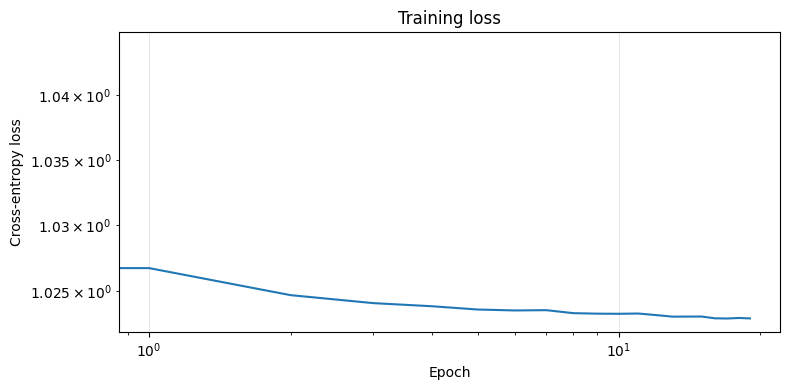

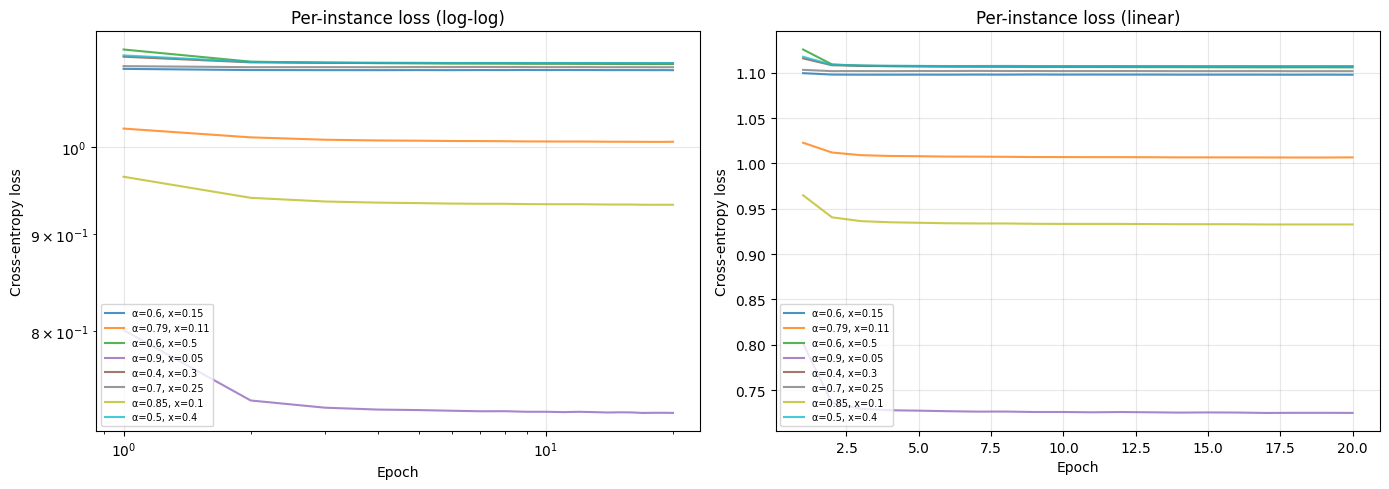

In [33]:
fig = plot_training_loss(losses)
fig.show()

fig2 = plot_per_instance_loss(instance_losses, instance_params)
fig2.show()

## 3. PCA of residual stream (per instance)

Collect residual stream activations at the last layer, split by Mess3 instance.

In [34]:
# Collect activations from all instances (shuffled)
N_SAMPLES = 4000
eval_loader = DataLoader(dataset, batch_size=256, shuffle=True)

all_residuals = []
all_instance_ids = []
n_collected = 0

model.eval()
with torch.no_grad():
    for tokens, inst_ids in tqdm(eval_loader, desc="Collecting activations"):
        tokens = tokens.to(device)
        h = model.residual_stream(tokens)  # (B, L, d_model)
        all_residuals.append(h[:, -1, :].cpu().numpy())
        all_instance_ids.append(inst_ids.numpy())
        n_collected += tokens.shape[0]
        if n_collected >= N_SAMPLES:
            break

residuals = np.concatenate(all_residuals)[:N_SAMPLES]
instance_ids = np.concatenate(all_instance_ids)[:N_SAMPLES]
print(f"Collected {residuals.shape[0]} activations of dim {residuals.shape[1]}")

Collected 4000 activations of dim 120


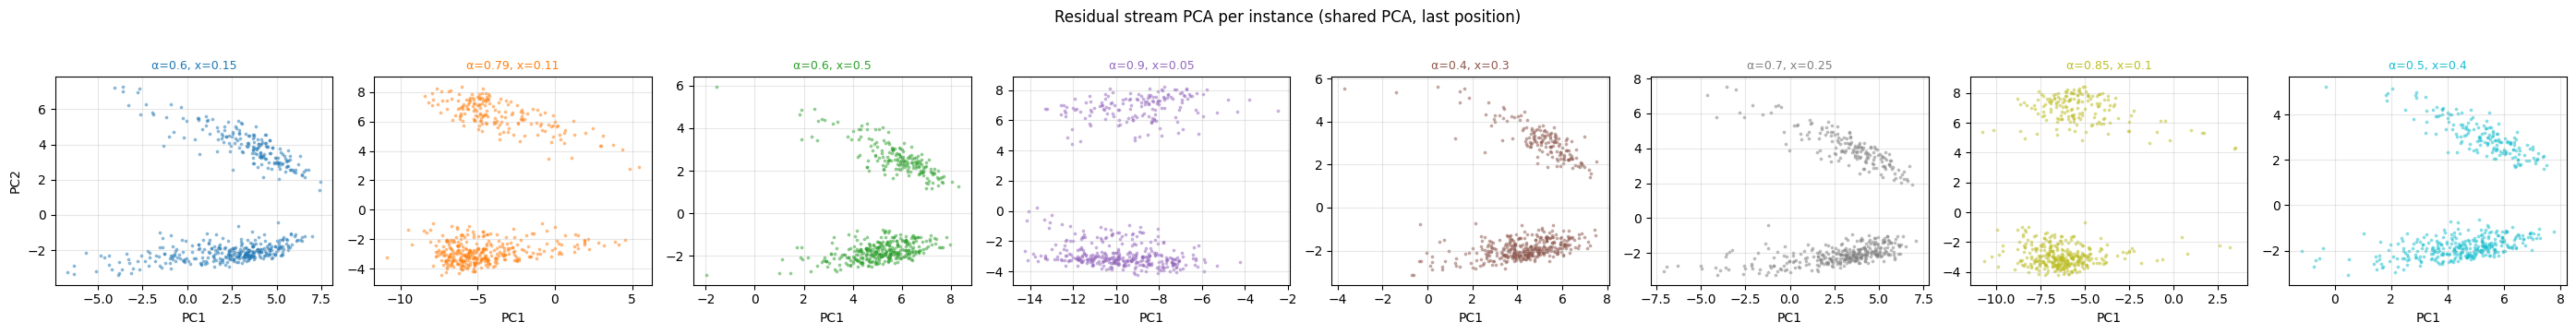

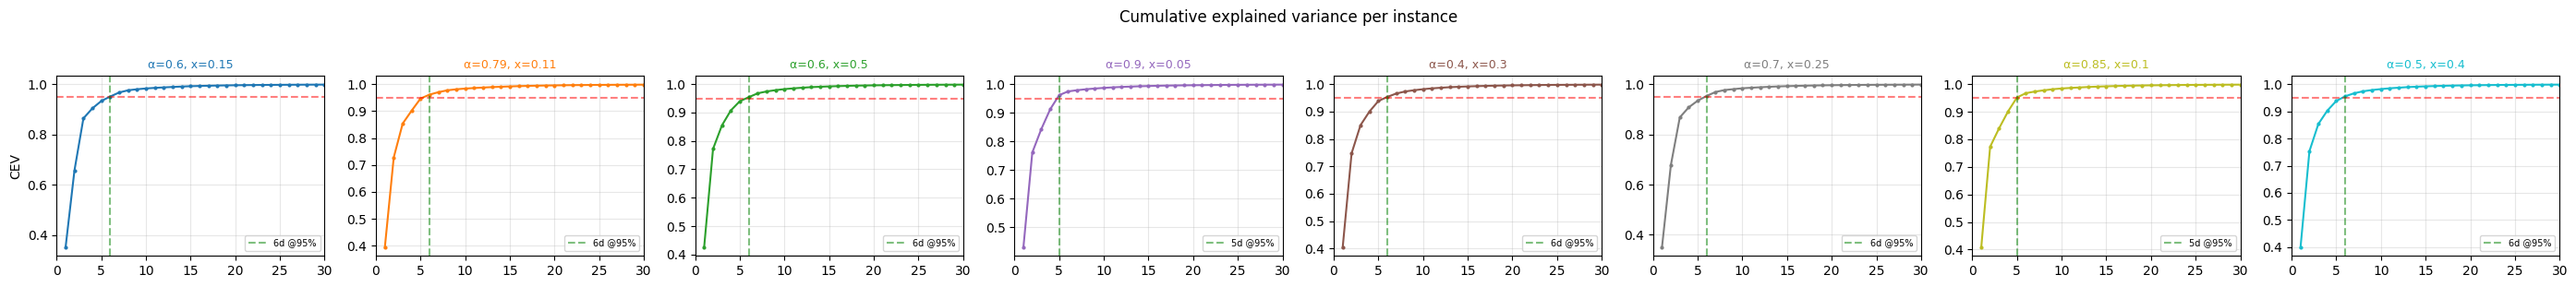

In [35]:
fig1 = plot_pca_per_instance(residuals, instance_ids, instance_params)
fig1.show()

fig2 = plot_cev_per_instance(residuals, instance_ids, instance_params)
fig2.show()

## 4. Training dynamics: steps × instances PCA grid

Rows = training steps (snapshots), columns = Mess3 instances.  
Shows how per-instance residual stream geometry evolves during training.

Snapshots: 100%|██████████| 8/8 [00:00<00:00, 20.60it/s]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/epoch_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,██▆▅▃▂▂▃▃▃▅▄▃▄▄▁▃▄▄▃▃▂▃▃▅▃▄▄▃▃▂▄▃▃▃▃▃▃▅▂
train/step,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
epoch,19
train/epoch_loss,1.02292
train/loss,1.02169
train/step,6240


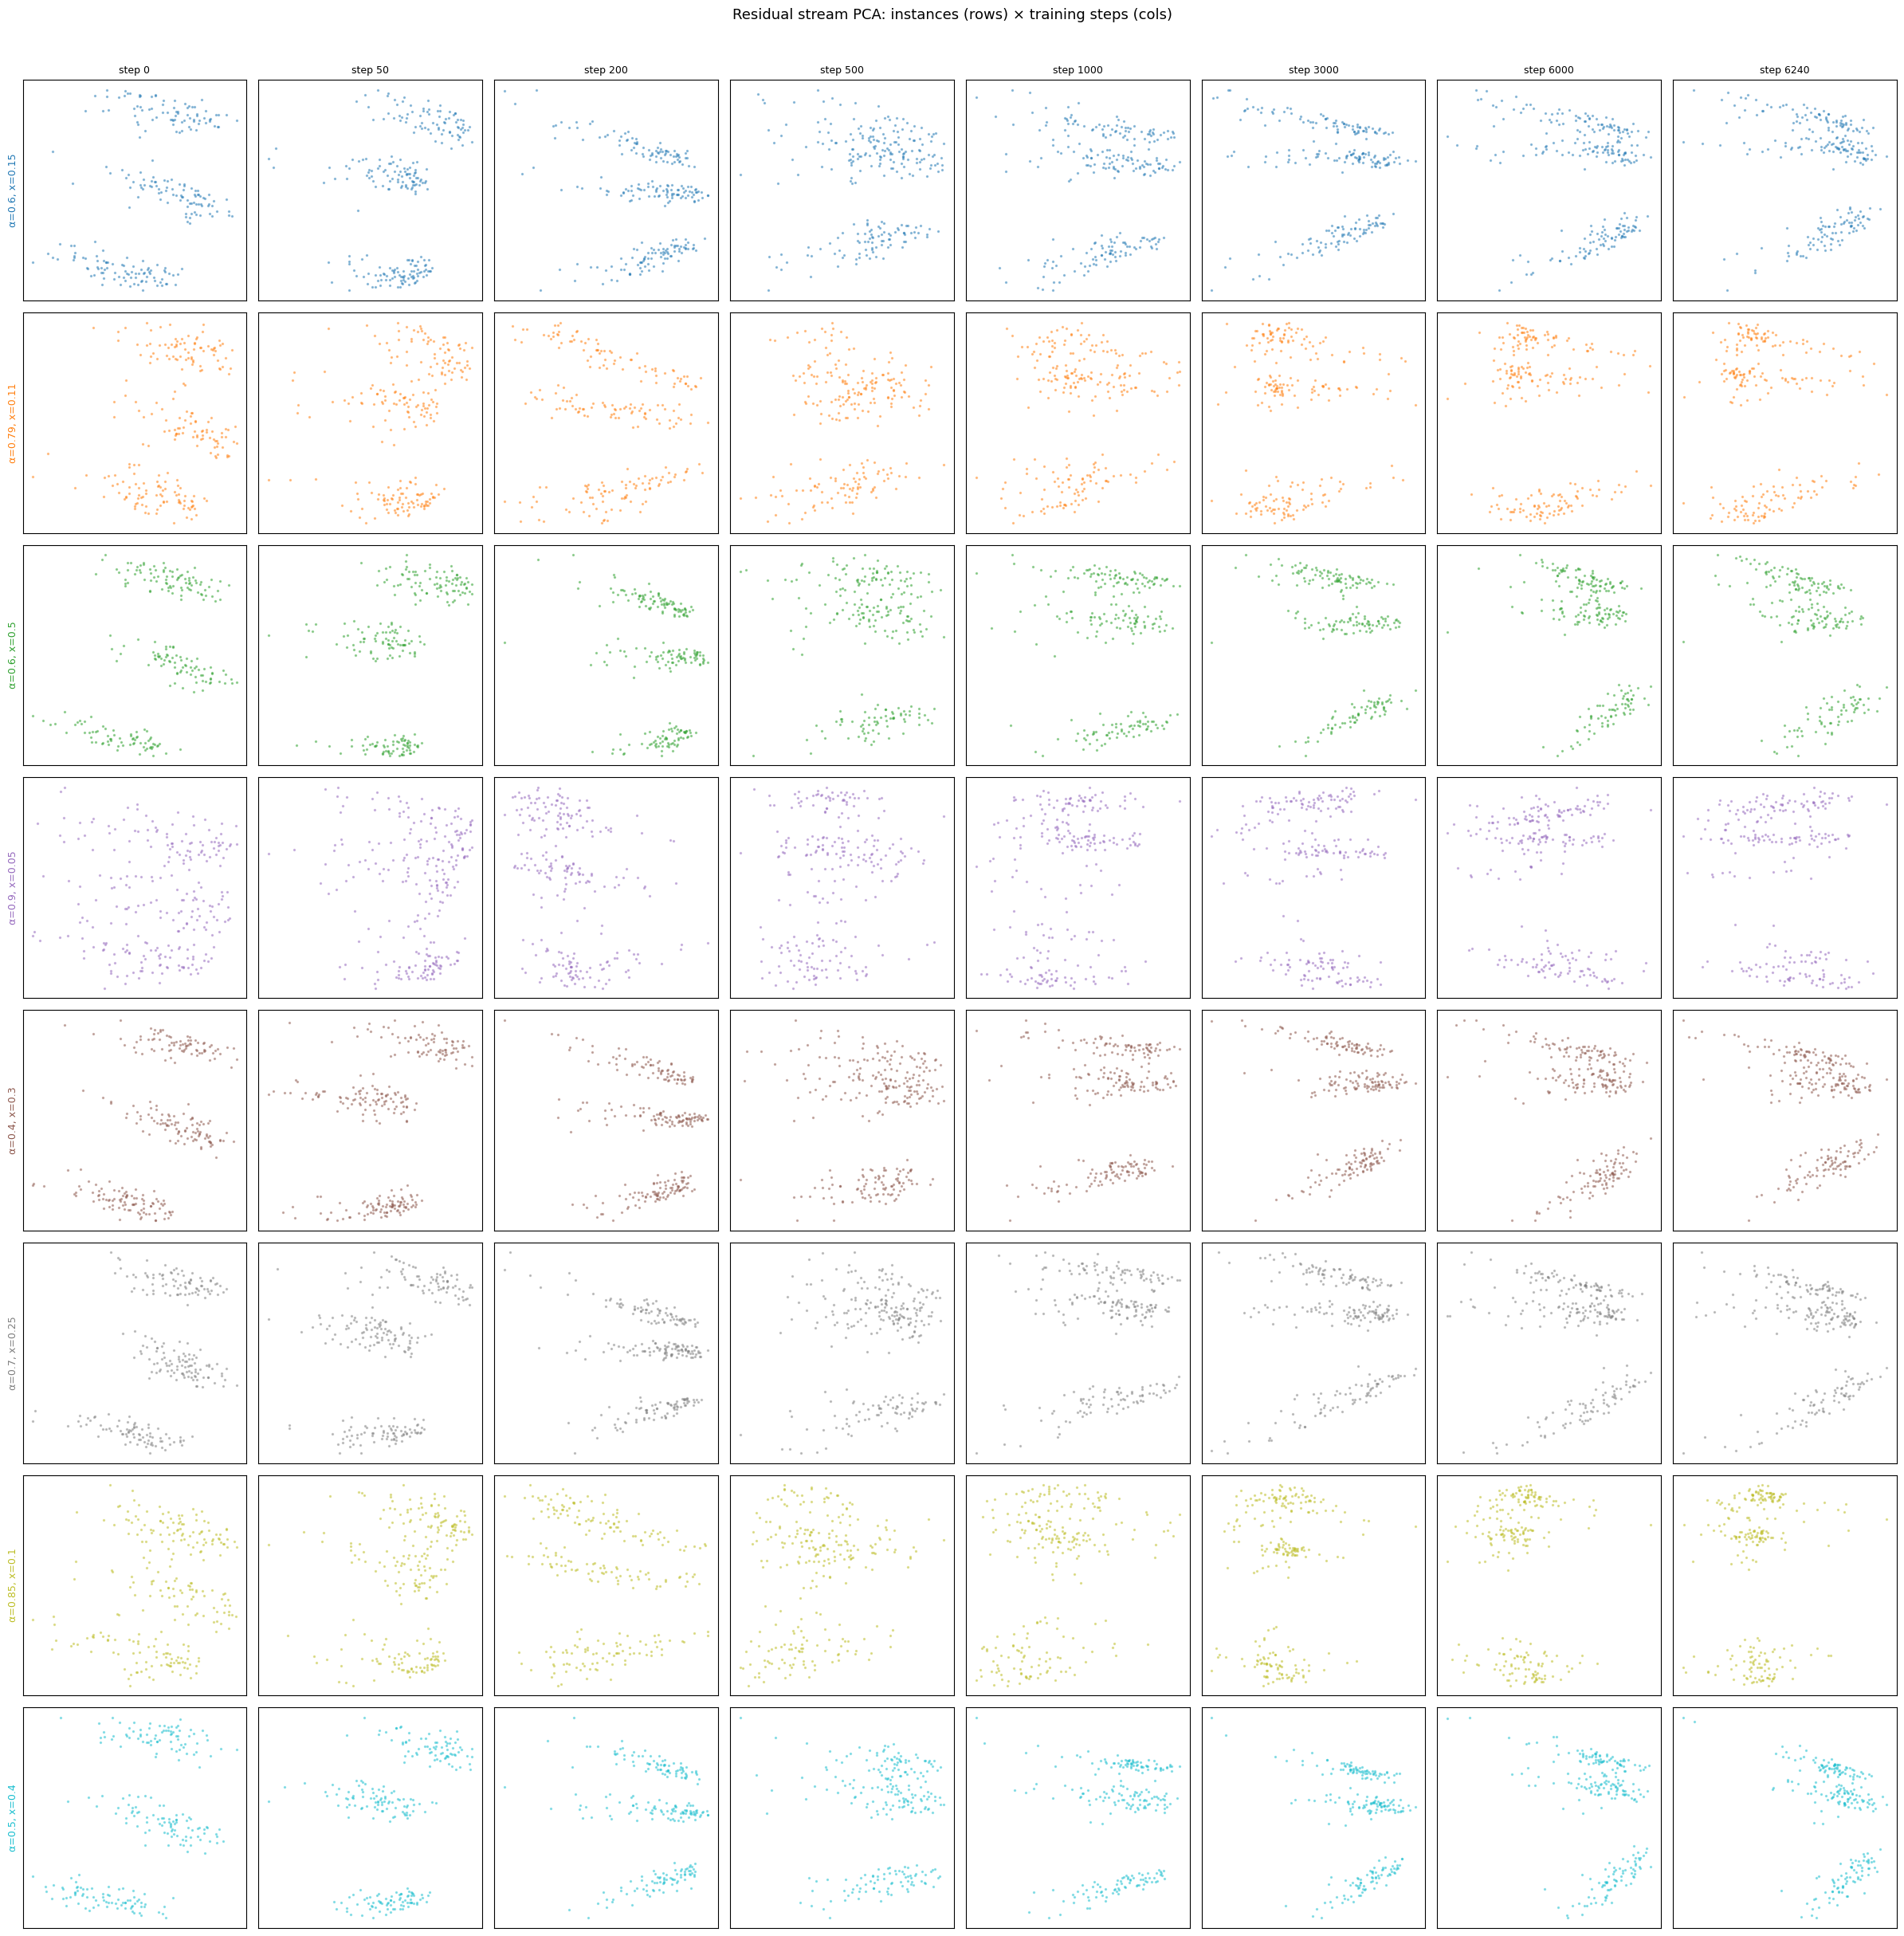

In [36]:
# Prepare a fixed eval batch (shuffled, covering all instances)
N_EVAL = 2000
eval_loader_grid = DataLoader(dataset, batch_size=256, shuffle=True)
eval_tokens_list, eval_ids_list = [], []
n = 0
for tok, ids in eval_loader_grid:
    eval_tokens_list.append(tok)
    eval_ids_list.append(ids)
    n += tok.shape[0]
    if n >= N_EVAL:
        break
eval_tokens = torch.cat(eval_tokens_list)[:N_EVAL].to(device)
eval_ids = torch.cat(eval_ids_list)[:N_EVAL].numpy()

# Collect residual streams for each snapshot
snap_steps = sorted(snapshots.keys())
n_inst = len(instances)

probe_model = GPT(vocab_size=3, d_model=120, n_heads=4, n_layers=4, d_mlp=480, max_len=SEQ_LEN).to(device)

# Fit shared PCA on final snapshot activations
probe_model.load_state_dict({k: v.to(device) for k, v in snapshots[snap_steps[-1]].items()})
probe_model.eval()
with torch.no_grad():
    h_final = probe_model.residual_stream(eval_tokens)[:, -1, :].cpu().numpy()
pca_shared = PCA(n_components=2).fit(h_final)

all_projs = {}
for s in tqdm(snap_steps, desc="Snapshots"):
    probe_model.load_state_dict({k: v.to(device) for k, v in snapshots[s].items()})
    probe_model.eval()
    with torch.no_grad():
        h = probe_model.residual_stream(eval_tokens)[:, -1, :].cpu().numpy()
    all_projs[s] = pca_shared.transform(h)

fig = plot_steps_x_instances_grid(all_projs, snap_steps, eval_ids, instance_params)
fig.show()

if wandb.run is not None:
    wandb.log({"pca/steps_x_instances": wandb.Image(fig)})
    wandb.finish()